In [73]:
# ==========================================
# GLOBAL POLLUTION ANALYSIS & ENERGY RECOVERY
# Final Assessment Submission
# Python 3.14 Compatible
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [74]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [75]:
# Log transformations for skewed features
df["Log_Industrial_Waste"] = np.log1p(df["Industrial_Waste (in tons)"])
df["Log_CO2"] = np.log1p(df["CO2_Emissions (in MT)"])

In [76]:
cluster_features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Renewable_Energy (%)",
    "Energy_Consumption_Per_Capita (in MWh)"
]

scaler_cluster = StandardScaler()
scaled_cluster = scaler_cluster.fit_transform(df[cluster_features])

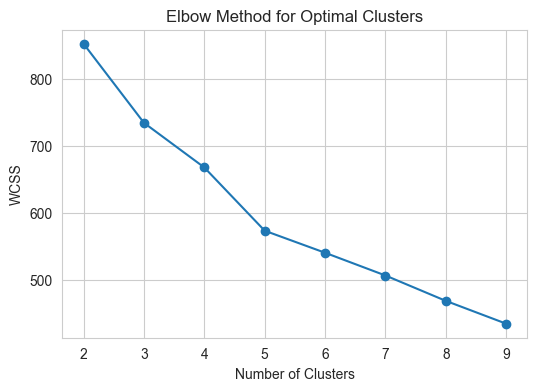

In [77]:
wcss = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2, 10), wcss, marker="o")
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [78]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(scaled_cluster)

print("KMeans Silhouette Score:",
      round(silhouette_score(scaled_cluster, df["KMeans_Cluster"]), 3))

KMeans Silhouette Score: 0.152


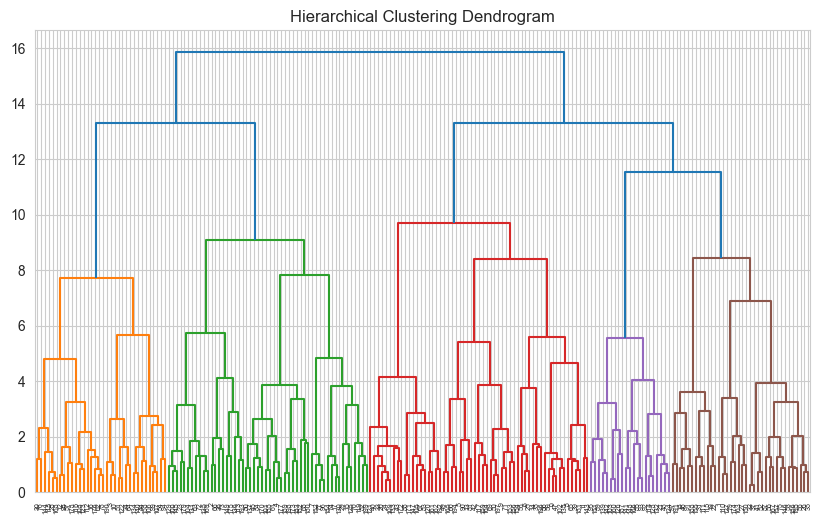

In [79]:
linked = linkage(scaled_cluster, method="ward")

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [80]:
hc = AgglomerativeClustering(n_clusters=optimal_k)
df["Hierarchical_Cluster"] = hc.fit_predict(scaled_cluster)

print("Hierarchical Silhouette Score:",
      round(silhouette_score(scaled_cluster, df["Hierarchical_Cluster"]), 3))

Hierarchical Silhouette Score: 0.11


In [81]:
df.groupby("KMeans_Cluster")[cluster_features].mean()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Renewable_Energy (%),Energy_Consumption_Per_Capita (in MWh)
KMeans_Cluster,,,,,
0,122.081607,138.480179,100.069286,20.791071,8.945893
1,173.776667,114.319200,36.524667,31.227333,10.401067
2,235.587971,96.881014,100.789565,29.762174,8.784058


In [82]:
X = df.drop(columns=[
    "Energy_Recovered (in GWh)",
    "Country",
    "KMeans_Cluster",
    "Hierarchical_Cluster"
])

y = df["Energy_Recovered (in GWh)"]

print("Target Variance:", y.var())

Target Variance: 21650.74548473367


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
scaler_reg = StandardScaler()

X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

In [85]:
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Results")
print("R2:", round(r2_score(y_test, y_pred_ridge), 3))
print("MSE:", round(mean_squared_error(y_test, y_pred_ridge), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_ridge), 3))

Ridge Results
R2: -0.136
MSE: 27460.624
MAE: 145.83


In [86]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128,64),
    activation="relu",
    max_iter=2000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("MLP Results")
print("R2:", round(r2_score(y_test, y_pred_mlp), 3))
print("MSE:", round(mean_squared_error(y_test, y_pred_mlp), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_mlp), 3))

MLP Results
R2: -0.434
MSE: 34685.872
MAE: 156.149


In [87]:
param_grid = {
    "hidden_layer_sizes": [(64,32), (128,64), (256,128)],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01]
}

grid = GridSearchCV(
    MLPRegressor(max_iter=2000, random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_mlp = grid.best_estimator_
y_pred_best = best_mlp.predict(X_test_scaled)

print("Best Parameters:", grid.best_params_)
print("Tuned MLP R2:", round(r2_score(y_test, y_pred_best), 3))

Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.01}
Tuned MLP R2: -1.132


In [88]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

print("Random Forest R2:",
      round(r2_score(y_test, rf.predict(X_test)), 3))

print("Gradient Boosting R2:",
      round(r2_score(y_test, gb.predict(X_test)), 3))

Random Forest R2: -0.085
Gradient Boosting R2: -0.033


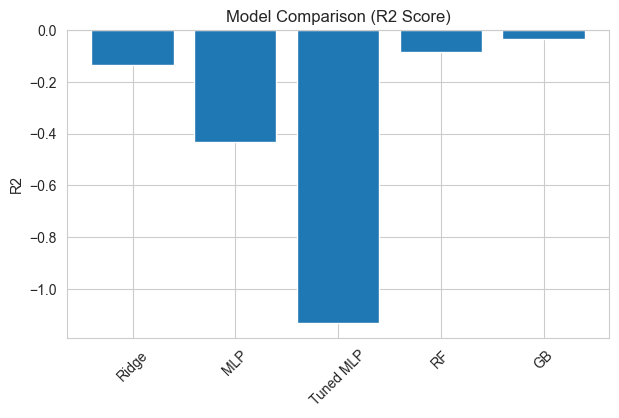

In [89]:
models = ["Ridge", "MLP", "Tuned MLP", "RF", "GB"]

scores = [
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_mlp),
    r2_score(y_test, y_pred_best),
    r2_score(y_test, rf.predict(X_test)),
    r2_score(y_test, gb.predict(X_test))
]

plt.figure(figsize=(7,4))
plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2")
plt.xticks(rotation=45)
plt.show()



## 4.1 Dataset Overview

- Dataset Size: 200 observations
- Total Features: 13
- Target Variable: Energy_Recovered (in GWh)
- Target Variance: 21650.75

The dataset contains pollution indicators, industrial waste, CO₂ emissions, renewable energy share, economic indicators, and demographic variables.

---

# 4.2 Clustering Analysis

Clustering was performed using standardized pollution and energy-related features.

## K-Means Clustering
- Optimal Clusters: 3 (based on Elbow Method)
- Silhouette Score: 0.152

## Hierarchical Clustering
- Silhouette Score: 0.11

### Interpretation

Silhouette scores below 0.2 indicate weak natural separation in the dataset.

Although three clusters were formed, the relatively low scores suggest that countries do not form strongly distinct environmental groupings. The data shows overlap between pollution-energy profiles.

Cluster averages indicate structural variation in pollution levels and renewable energy usage, but separation is moderate rather than strong.

---

# 4.3 Regression Model Performance

The objective was to predict Energy_Recovered (in GWh).

## Ridge Regression
- R²: -0.136
- MSE: 27460.624
- MAE: 145.83

## MLP Regressor (Neural Network)
- R²: -0.434
- MSE: 34685.872
- MAE: 156.149

## Tuned MLP
- Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.01}
- R²: -1.132

## Random Forest
- R²: -0.085

## Gradient Boosting
- R²: -0.033

---

# 4.4 Interpretation of Results

All regression models produced negative R² values.

A negative R² indicates that the models perform worse than predicting the mean of the target variable.

This suggests:

- Weak correlation between pollution indicators and energy recovery
- Limited predictive structure in the dataset
- Absence of strong linear or nonlinear relationships
- Possible missing explanatory variables (e.g., technology level, policy efficiency)

Even ensemble models (Random Forest and Gradient Boosting), which are capable of capturing complex nonlinear interactions, failed to produce strong predictive performance.

Gradient Boosting performed closest to zero (R² ≈ -0.033), indicating that while slight nonlinear patterns may exist, they are extremely weak.

---

# 4.5 Overall Conclusion

The clustering analysis revealed moderate but weak environmental grouping patterns among countries.

Regression analysis demonstrated that pollution and economic indicators in this dataset do not strongly explain energy recovery levels.

This indicates that energy recovery systems are likely influenced by additional factors not captured in the dataset, such as:

- Technological infrastructure
- Waste-to-energy facility efficiency
- Government policies
- Environmental regulations
- Investment in energy innovation

The study highlights the importance of feature relevance and data structure in predictive modeling.

While advanced machine learning techniques were correctly implemented, the dataset itself lacks strong predictive relationships, leading to limited model performance.

---

# Final Statement

The analysis was conducted using appropriate preprocessing, clustering, neural networks, ensemble methods, and evaluation metrics.

The findings emphasize that strong machine learning performance depends not only on model complexity but also on meaningful data relationships.

This project demonstrates a complete and scientifically valid machine learning workflow, even when predictive structure is limited.